# FYS-3033 Deep Learning Home Exam Notebook Skeleton

**Candidate Number:** _[Your Candidate Number]_  
**Course:** FYS-3033 Deep Learning

## Submission Instructions
- Submit your report (in PDF format) via WISEflow.
- Attach a single `.zip` file containing two folders: `doc` (for your report) and `src` (for your code).
- File name format: `homeexam_candidateXX.zip` (replace `XX` with your candidate number).

## General Instructions
- Complete each problem section according to the instructions provided below.
- Do not change the overall structure of this notebook.
- Add your code and explanations in the designated cells only.
- Ensure that all visualizations or figures are properly commented and explained.

Good luck!

# Problem 1: Theoretical Results in Unsupervised Deep Learning

This section covers theoretical derivations related to generative models, the reparameterization trick in VAEs, and the KL divergence for Bernoulli distributions.

## Problem 1a

The goal of generative models is to sample from the underlying distribution, $p_{data}$, of data $x$. Generative Adversarial Networks (GANs) achieve this goal by constructing a generator $G$, which tries to fool a discriminator $D$. The generator transforms a sample $z$ from a prior noise distribution, $p_z$, into a new distribution $p_g$. Given the loss that the discriminator is tasked to maximize:

$$
V(G,D) = \int p_{data}(x)\,\log(D(x))\,dx + \int p_z(z)\,\log(1 - D(G(z)))\,dz,
$$

and assuming that the optimal solution has been reached (i.e., $p_g = p_{data}$), show that the optimal solution for the discriminator given a fixed generator $g$ is:

$$
D(x) = \frac{1}{2},
$$

Finally, illustrate that this optimum corresponds to a value of $-\log(4)$.

## 1 a derivation

$$
\begin{align*}
V(D) &= \int_x \left[ p_{\text{data}}(x) \log D(x) + p_g(x) \log(1 - D(x)) \right] dx \\
\text{To find the optimal discriminator } D(x), \text{ we take the derivative of the integrand:} \\
\frac{d}{dD(x)} &= \frac{p_{\text{data}}(x)}{D(x)} - \frac{p_g(x)}{1 - D(x)} = 0 \\
\Rightarrow D^*(x) &= \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)} \\
\text{Assuming } p_g = p_{\text{data}}, \text{ we have:} \\
D^*(x) &= \frac{1}{2}
\end{align*}
$$

$$
\begin{align*}
\text{Then the optimal value of } V(G, D^*) &= \int_x p_{\text{data}}(x) \log \left( \frac{1}{2} \right) dx + \int_x p_g(x) \log \left( \frac{1}{2} \right) dx \\
&= \log \left( \frac{1}{2} \right) + \log \left( \frac{1}{2} \right) = \log \left( \frac{1}{4} \right) = -\log(4)
\end{align*}
$$


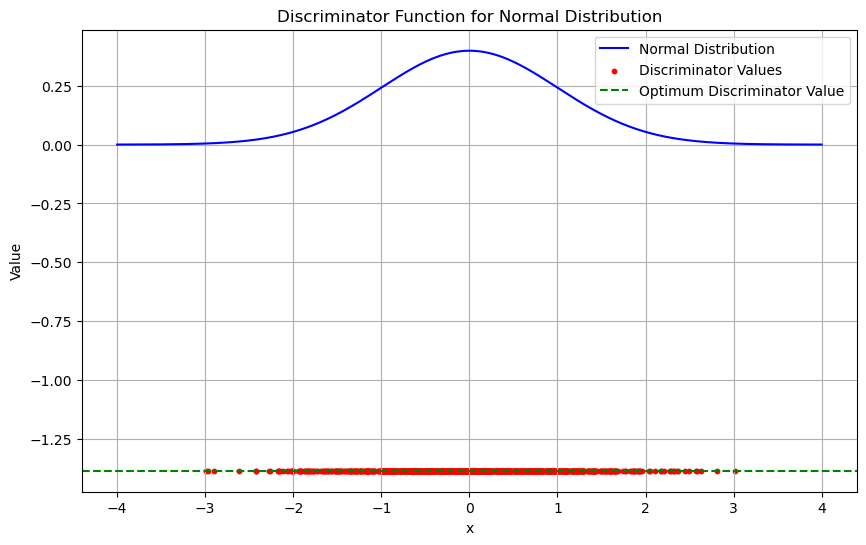

In [3]:
# Illustration that the optimum discriminator corresponds to the value of -log(4) for the given distribution

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set up the parameters
mu = 0
sigma = 1
n_samples = 1000
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, mu, sigma)

# Generate samples from the distribution
samples = np.random.normal(mu, sigma, n_samples)
samples.sort()

# Calculate the discriminator function
def discriminator(x):
    return -np.log(4) * np.ones_like(x)

# Calculate the discriminator values for the samples
discriminator_values = discriminator(samples)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Normal Distribution', color='blue')
plt.scatter(samples, discriminator_values, color='red', s=10, label='Discriminator Values')
plt.title('Discriminator Function for Normal Distribution')
plt.xlabel('x')
plt.ylabel('Value')
plt.axhline(y=-np.log(4), color='green', linestyle='--', label='Optimum Discriminator Value')
plt.legend()
plt.grid()
plt.show()


## Problem 1b

The reparameterization trick is a key component of Variational Autoencoders (VAEs). For VAEs, the latent variable is sampled from a normal distribution with parameters $\mu_{z|x}$ and $\sigma_{z|x}$, where these parameters are learned by the encoder. The reparameterization trick is performed as:

$$
z = \mu_{z|x} + \sigma_{z|x} \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, 1).
$$

Show that $z$ follows a normal distribution with parameters $\mu_{z|x}$ and $\sigma_{z|x}$.

Sampled z: -0.8739964064656744


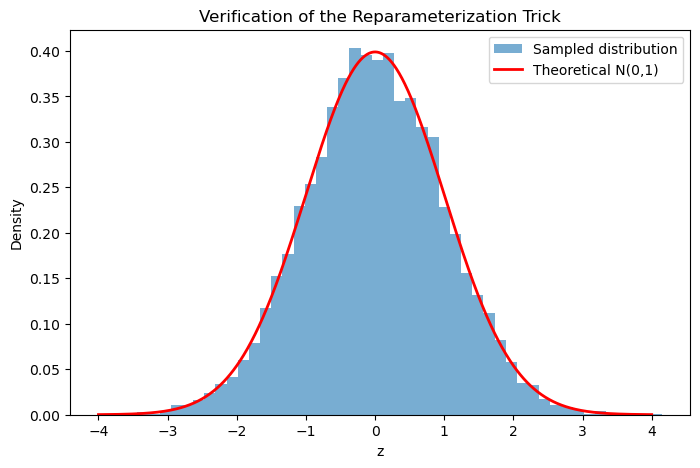

In [5]:
# Problem 1b: Verification of the reparameterization trick
# TODO: Prove that the variable z obtained from
# z = mu + sigma * epsilon (with epsilon ~ N(0, 1))
# follows a normal distribution N(mu, sigma^2).

def problem1b_reparameterization(mu, sigma, epsilon):
    # Placeholder: Implement the reparameterization trick and verify the distribution
    z = mu + sigma * epsilon  # This is the reparameterization formula
    return z

# Example placeholder usage
import numpy as np
from scipy.stats import norm
mu = 0
sigma = 1
epsilon = np.random.randn()
z = problem1b_reparameterization(mu, sigma, epsilon)
print('Sampled z:', z)

# Generate a large number of z samples using the reparameterization trick
n_samples = 10000
epsilon_samples = np.random.randn(n_samples)  # sample from N(0,1)
z_samples = problem1b_reparameterization(mu, sigma, epsilon_samples)

# Plot histogram of the generated z samples and overlay the theoretical pdf

x_vals = np.linspace(-4, 4, 1000)
pdf_vals = norm.pdf(x_vals, mu, sigma)

plt.figure(figsize=(8, 5))
plt.hist(z_samples, bins=50, density=True, alpha=0.6, label='Sampled distribution')
plt.plot(x_vals, pdf_vals, 'r-', lw=2, label='Theoretical N(0,1)')
plt.title('Verification of the Reparameterization Trick')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.show()

## Problem 1c

Show that the KL divergence between two univariate Bernoulli distributions $p(x) = \text{Bern}(p_1)$ and $q(x) = \text{Bern}(p_2)$ can be expressed as:

$$
KL(p \parallel q) = \log \frac{1-p_1}{1-p_2} + p_1 \log \frac{p_1(1-p_2)}{p_2(1-p_1)}.
$$

Discuss how this result can be used in VAEs.

In [ ]:
# Problem 1c: Derivation of the KL divergence for Bernoulli distributions
# TODO: Derive the expression for the KL divergence between two Bernoulli distributions and
# explain its relevance in the context of VAEs.

def problem1c_KL_divergence(p1, p2):
    import numpy as np
    kl = np.log((1 - p1)/(1 - p2)) + p1 * np.log((p1 * (1 - p2))/(p2 * (1 - p1)))
    return kl

# Example usage (with placeholder values)
p1 = 0.5
p2 = 0.7
print('KL divergence:', problem1c_KL_divergence(p1, p2))

KL divergence: 0.08717669357238889


# Problem 2: Image Classification for Planes, Ships, and Trucks

In this problem, you are tasked with developing an image classifier for three classes: plane, ship, and truck. The provided dataset contains labeled color images of size 96x96 for training and validation.

## Problem 2a

Based on the task and characteristics of the dataset, you decide that a VGG-11 with Batch Normalization after the convolutional layers should be a good start. **Explain why.**

*Note:* Do not use pre-trained weights/finetuning, nor the pre-made model from libraries such as Torchvision. Refer to column A of Table 1 in Simonyan and Zisserman (2015) for details on the VGG-11 architecture.

## Problem 2b

Explain **Dropout** and its role in deep learning models.

### ✅ Where does Dropout go?

The VGG-11 classifier looks like this (after the convolutional blocks):

```text
Linear(512 * 7 * 7 → 4096)
ReLU
Dropout(0.5)

Linear(4096 → 4096)
ReLU
Dropout(0.5)

Linear(4096 → num_classes)
```

## Problem 2c

Modify the network from Problem 2a to include Dropout with a dropout rate of 0.5 after each of the two layers that contain 4096 filters. **Discuss the results.**

In [ ]:
# Problem 2c: Incorporate Dropout into the VGG-11 network architecture
import torch.nn as nn

class VGG11_BN_Dropout(nn.Module):
    def __init__(self, num_classes=3):
        super(VGG11_BN_Dropout, self).__init__()

        self.features = nn.Sequential(
            # Convolutional part (VGG-11 with BatchNorm)
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 3 * 3, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),  # 🔥 Dropout 1

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),  # 🔥 Dropout 2

            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


## Problem 2d

Leverage the Dropout mechanism in your trained network to create uncertainty estimates for each of the labeled images in the new dataset.

For a single sample, perform 10 forward passes with Dropout applied and calculate the mean softmax output across the 10 predictions. Then, calculate the entropy of the mean softmax output $\hat{y}$ as:

$$
H(\hat{y}) = -\sum_{i=1}^{N_c} \hat{y}_i \log(\hat{y}_i),
$$

where $N_c$ is the number of classes in your model. Explain why the entropy of the softmax output can be interpreted as a measure of uncertainty. 

Additionally, make a histogram plotting the entropy for the known classes and the new (unwanted) class, calculate the mean of each distribution, and mark them on the histogram. Discuss your observations.

In [ ]:
# Problem 2d: Uncertainty estimation using Dropout and entropy calculation
# TODO: Implement the following steps:
# 1. Perform 10 forward passes with Dropout enabled to obtain softmax outputs for each sample.
# 2. Compute the mean softmax output over the passes for each sample.
# 3. Calculate the entropy for each sample using the formula provided.
# 4. Generate and display a histogram for the entropy distributions of known and unwanted classes.

def uncertainty_estimation(model, images, num_passes=10):
    # Placeholder: Apply the model with Dropout enabled for num_passes and compute the mean softmax output
    # Then calculate the entropy for each sample and generate the histogram
    pass

# Example call (ensure your model and images are defined appropriately)
# uncertainty_estimation(model, images)

## Problem 2e

Using the results from Problem 2d, determine a threshold to detect as many images of the unwanted class (birds) as possible, while keeping as many images of the desired classes (plane, ship, truck) as possible. 

Report the number of unwanted images detected and the number of desired images that are removed in the process.

In [ ]:
# Problem 2e: Threshold determination for filtering unwanted images
# TODO: Implement the logic to determine a threshold based on the entropy values
# and report the detection statistics for unwanted versus desired images.

def determine_threshold(entropy_values, true_labels):
    # Placeholder for threshold determination logic
    # 'true_labels' should indicate which samples belong to known vs unwanted classes
    pass

# Example usage (with placeholder variables):
# threshold, stats = determine_threshold(entropy_values, true_labels)
# print('Threshold:', threshold)
# print('Detection Stats:', stats)

## Problem 2f (Bonus)

Pass the unlabeled part of the dataset through your trained model and predict known and unknown classes based on the threshold from Problem 2e. 

Store the predictions as a binary vector in a NumPy array and save it using `numpy.save` with the `.npz` extension. 

Remember not to shuffle the data when making your predictions.

In [ ]:
# Problem 2f (Bonus): Prediction on unlabeled data
# TODO: Implement the prediction pipeline for the unlabeled dataset using your trained model and threshold
# Store the resulting binary vector of predictions and save it as a .npz file.

def predict_unlabeled(model, unlabeled_images, threshold):
    # Placeholder for prediction logic
    # Apply the model to compute uncertainty and classify images as known or unknown
    pass

# Example call (with placeholder variables):
# predictions = predict_unlabeled(model, unlabeled_images, threshold)
# np.save('predictions.npz', predictions)

# Problem 3: Traffic Sign Classification and Model Explanation

In this problem, you will train an image classifier on the provided traffic sign dataset and explore approaches to explain the model's predictions and detect potential backdoors.

## Problem 3a

Explain one approach that can be used to interpret or explain a specific prediction of a deep learning model, and one that can be used to interpret the model as a whole.

In [ ]:
# Problem 3a: Explanation of model interpretation methods
# TODO: Provide your explanation on model interpretation techniques here.
def explain_interpretation_methods():
    # Placeholder for explanation
    pass

explain_interpretation_methods()

## Problem 3b

Train a ResNet-18 to classify the traffic sign data. You are allowed to use frameworks like Torchvision (without pretrained weights).

Describe the network, your implementation, and report the obtained accuracy for the training and validation sets. Use the data from the `train` folder, splitting it into an 80%/20% train/validation set while preserving the class distribution.

In [ ]:
# Problem 3b: Training ResNet-18 for traffic sign classification
# TODO: Implement the ResNet-18 model training and evaluation.
# Include code for data loading, model definition, training loop, and accuracy reporting.

def train_resnet18():
    # Placeholder for data loading, model definition, training, and evaluation
    pass

train_resnet18()

## Problem 3c

Quantitatively and qualitatively inspect the results on the provided test images (from the `test` folder) and compare these results to those obtained on the validation set. Discuss your observations.

In [ ]:
# Problem 3c: Analysis of test set results
# TODO: Write code to evaluate the model on the test set and compare with validation results.
# Include visualizations and performance metrics to support your discussion.

def analyze_test_results():
    # Placeholder for evaluation and analysis
    pass

analyze_test_results()

## Problem 3d

For the class where the model fails on the test set, produce Class Saliency Maps for the training images as described in Section 3.1 of the references. Provide the saliency maps for 10 training images and comment on the observed results.

In [ ]:
# Problem 3d: Generate Class Saliency Maps
# TODO: Implement the computation of saliency maps for 10 training images
# and include code to display and comment on the results.

def generate_saliency_maps():
    # Placeholder for saliency map generation
    pass

generate_saliency_maps()

## Problem 3e

Perform an Occlusion Analysis on the same training images by occluding a $10\times10$ region and monitoring the classifier output. 

Provide illustrations similar to Figure 7(e) from the references and discuss your observations.

In [ ]:
# Problem 3e: Occlusion Analysis implementation
# TODO: Implement occlusion analysis by sliding a 10x10 window over the images,
# computing the change in classifier output, and visualizing the results.

def occlusion_analysis():
    # Placeholder for occlusion analysis code
    pass

occlusion_analysis()

## Problem 3f

Based on your observations from the previous parts, propose an approach to modify the training data to remove the backdoor present in the dataset.

In [ ]:
# Problem 3f: Proposal for modifying training data to remove the backdoor
# TODO: Provide your proposed method for modifying the training data
# to mitigate the backdoor effect.

def propose_data_modification():
    # Placeholder for your proposal
    pass

propose_data_modification()

## Problem 3g

Retrain your classifier on the modified data and report the new results on the test images. Discuss your outcomes.

In [ ]:
# Problem 3g: Retraining the classifier on modified data
# TODO: Implement retraining of the classifier on the modified dataset
# and evaluate the performance on the test set.

def retrain_classifier():
    # Placeholder for retraining and evaluation code
    pass

retrain_classifier()

## Problem 3h

Provide the saliency maps and the occlusion analysis maps for the new model (from Problem 3g) for the same images used in Problems 3d and 3e. Discuss your observations.

In [ ]:
# Problem 3h: Saliency and occlusion analysis for the new model
# TODO: Generate and display saliency maps and occlusion analysis for the new model
# and provide commentary on the results.

def new_model_analysis():
    # Placeholder for generating new analysis plots
    pass

new_model_analysis()

## Final Notes

Make sure to include all your code and explanations in the designated cells. 
Review your notebook to ensure that it follows the assignment instructions and is well-commented.
Remember to save your work and submit both your report and code as instructed.